In [25]:
# @title 1. Load "Big Data" Cohort (All Sepsis + 15k Controls)
from google.colab import auth
from google.cloud import bigquery
import pandas as pd

auth.authenticate_user()
project_id = 'sepsis-prediction-2025' # Your Project ID
client = bigquery.Client(project=project_id)

# 1. Get ALL Sepsis Patients (No Limit)
# We prioritize these because they are the rare "Gold" signal
query_pos = """
SELECT
    stay_id,
    subject_id,
    sepsis_onset_time AS prediction_time,
    1 AS label
FROM `sepsis-prediction-2025.my_sepsis_data.sepsis_cohort`
"""

print("Fetching ALL Sepsis cases...")
df_pos = client.query(query_pos).to_dataframe()

# Clean duplicates (keep first sepsis event per patient)
df_pos = df_pos.sort_values('prediction_time').groupby('stay_id').first().reset_index()
df_pos['label'] = 1 # Ensure float/int consistency later

print(f"Found {len(df_pos)} total unique Sepsis patients.")

# 2. Get 15,000 Controls (Larger Negative Sample)
# We increase this from 2k to 15k to teach the model what "Normal" looks like
query_neg = """
SELECT
    icu.stay_id,
    icu.subject_id,
    DATETIME_ADD(icu.intime, INTERVAL 24 HOUR) AS prediction_time,
    0 AS label
FROM `physionet-data.mimiciv_3_1_icu.icustays` icu
WHERE icu.stay_id NOT IN (
    SELECT stay_id FROM `sepsis-prediction-2025.my_sepsis_data.sepsis_cohort`
)
LIMIT 15000
"""

print("Fetching 15,000 Control cases...")
df_neg = client.query(query_neg).to_dataframe()

# 3. Combine
df_final = pd.concat([df_pos, df_neg], ignore_index=True)

print("-" * 30)
print(f"SCALED DATASET: {len(df_final)} patients")
print(f"Sepsis (Pos): {len(df_pos)}")
print(f"Control (Neg): {len(df_neg)}")
print(f"Imbalance Ratio: 1 Positive : {len(df_neg)/len(df_pos):.1f} Negatives")

Fetching ALL Sepsis cases...
Found 15049 total unique Sepsis patients.
Fetching 15,000 Control cases...
------------------------------
SCALED DATASET: 30049 patients
Sepsis (Pos): 15049
Control (Neg): 15000
Imbalance Ratio: 1 Positive : 1.0 Negatives


In [34]:
# @title 2. Safe Feature Fetch (Differential Diagnosis Edition)
import pandas as pd
import numpy as np

# 1. Get unique IDs from Step 1
all_ids = df_final['stay_id'].unique().tolist()
CHUNK_SIZE = 5000 # Download in batches to prevent crashes
chunks = [all_ids[i:i + CHUNK_SIZE] for i in range(0, len(all_ids), CHUNK_SIZE)]

print(f"Split {len(all_ids)} patients into {len(chunks)} download chunks...")

df_events_list = []
df_static_list = []

# 2. Define the "Differential Diagnosis" Item IDs
# We fetch everything in one pass to save time
LAB_ITEM_IDS = (
    50813, # Lactate (Sepsis)
    51301, # WBC (Infection)
    50912, # Creatinine (Kidney)
    50931, # Glucose (DKA check)
    51003, # Troponin T (Cardiac check)
    50956, # Lipase (Pancreatitis check)
    50885, # Bilirubin (Liver check)
    51265, # Platelets (Clotting/DIC)
    50882, # Bicarbonate (Acidosis type)
    51006  # BUN (Dehydration vs Renal)
)

VITAL_ITEM_IDS = (
    220045, # HR
    220179, 220050, # SBP (Invasive & Non-Invasive)
    220277, # O2 Sat
    220210, # RR
    223761  # Temp F
)

# 3. Loop through chunks
for i, chunk in enumerate(chunks):
    print(f"Downloading Chunk {i+1}/{len(chunks)}...")
    chunk_tuple = str(tuple(chunk))

    # Dynamic Data Query (Vitals + Extended Labs)
    q_events = f"""
    WITH target_patients AS (
        SELECT stay_id, subject_id FROM `physionet-data.mimiciv_3_1_icu.icustays`
        WHERE stay_id IN {chunk_tuple}
    ),
    vitals AS (
        SELECT stay_id, charttime, itemid, valuenum
        FROM `physionet-data.mimiciv_3_1_icu.chartevents`
        WHERE stay_id IN {chunk_tuple}
        AND itemid IN {VITAL_ITEM_IDS}
    ),
    labs AS (
        SELECT ie.stay_id, le.charttime, le.itemid, le.valuenum
        FROM `physionet-data.mimiciv_3_1_hosp.labevents` le
        JOIN target_patients ie ON le.subject_id = ie.subject_id
        WHERE le.itemid IN {LAB_ITEM_IDS}
    )
    -- Combine them into one vertical list
    SELECT stay_id, charttime, itemid, valuenum FROM vitals
    UNION ALL
    SELECT stay_id, charttime, itemid, valuenum FROM labs
    """
    df_events_list.append(client.query(q_events).to_dataframe())

    # Static Data Query (Age/Gender)
    q_static = f"""
    SELECT ie.stay_id, p.anchor_age, p.gender
    FROM `physionet-data.mimiciv_3_1_icu.icustays` ie
    JOIN `physionet-data.mimiciv_3_1_hosp.patients` p ON ie.subject_id = p.subject_id
    WHERE ie.stay_id IN {chunk_tuple}
    """
    df_static_list.append(client.query(q_static).to_dataframe())

# 4. Combine Results
df_events = pd.concat(df_events_list, ignore_index=True)
df_static = pd.concat(df_static_list, ignore_index=True)

# Pre-process Static Data
df_static['is_male'] = df_static['gender'].apply(lambda x: 1 if x == 'M' else 0)
df_static = df_static[['stay_id', 'anchor_age', 'is_male']]

print("-" * 30)
print(f"SUCCESS: Downloaded {len(df_events)} events (Vitals + 10 Labs)")
print(f"Patient Count: {len(df_static)}")

Split 30049 patients into 7 download chunks...
------------------------------
SUCCESS: Downloaded 28857671 events (Vitals + 10 Labs)
Patient Count: 30049


In [57]:
# @title 1. Time-Aware Data Processor (Values + Masks)
from tqdm import tqdm
tqdm.pandas()

# 15 Dynamic Features
DYNAMIC_FEATURES = [
    'HR', 'SBP', 'O2Sat', 'RR', 'Temp',
    'Lactate', 'WBC', 'Creatinine',
    'Glucose', 'Troponin', 'Lipase', 'Bilirubin', 'Platelets', 'Bicarbonate', 'BUN'
]

def process_patient_time_aware(group):
    # A. Pivot for VALUES (The actual numbers)
    pivoted_val = group.pivot_table(index='charttime', columns='feature', values='valuenum', aggfunc='mean')
    pivoted_val = pivoted_val.reindex(columns=DYNAMIC_FEATURES, fill_value=np.nan)

    # B. Pivot for MASKS (1 = Measured, 0 = Missing)
    # We count entries; if count > 0, it was measured
    pivoted_mask = group.pivot_table(index='charttime', columns='feature', values='valuenum', aggfunc='count')
    pivoted_mask = pivoted_mask.reindex(columns=DYNAMIC_FEATURES, fill_value=0)
    pivoted_mask = (pivoted_mask > 0).astype(float) # Convert to 1.0 / 0.0

    # C. Resample Time Grid
    end_time = group['prediction_time'].iloc[0]
    start_time = end_time - pd.Timedelta(hours=24)
    full_idx = pd.date_range(start=start_time, end=end_time, freq='1h')[:-1]

    # D. Reindex & Fill
    # Values: Forward Fill (Carry forward last known) -> then Fill 0
    resampled_val = pivoted_val.reindex(full_idx).ffill(limit=24).fillna(0)

    # Masks: Fill 0 (If no data in that specific hour, mask is 0)
    # We do NOT forward fill masks. A test taken 5 hours ago is "0" now.
    resampled_mask = pivoted_mask.reindex(full_idx).fillna(0)

    # E. Concatenate (Horizontal Stack: [Values | Masks])
    # Shape becomes (24, 30) -> 15 values + 15 masks
    combined_dynamic = np.hstack([resampled_val.values, resampled_mask.values])

    return combined_dynamic.astype(np.float32)

print("Processing Time-Aware Tensors...")
# Apply the new processor
time_aware_series = df_clean.groupby('stay_id', group_keys=False).progress_apply(process_patient_time_aware)

# Stack
X_dynamic_time = np.stack(time_aware_series.values)
valid_ids_time = time_aware_series.index
y_final_time = df_final[df_final['stay_id'].isin(valid_ids_time)].set_index('stay_id').loc[valid_ids_time, 'label'].values.astype(np.float32)

# Align Static
df_static_aligned = df_static.set_index('stay_id').loc[valid_ids_time].reset_index()
X_static_time = df_static_aligned[['anchor_age', 'is_male']].values.astype(np.float32)

# Fuse: [30 Dynamic] + [2 Static] = 32 Features
static_expanded = np.repeat(np.expand_dims(X_static_time, axis=1), 24, axis=1)
X_fused_time_aware = np.concatenate([X_dynamic_time, static_expanded], axis=2)

print(f"TIME-AWARE SHAPE: {X_fused_time_aware.shape} (Should be ~30000, 24, 32)")

Processing Time-Aware Tensors...


100%|██████████| 29986/29986 [06:19<00:00, 78.96it/s]


TIME-AWARE SHAPE: (29986, 24, 32) (Should be ~30000, 24, 32)


In [58]:
# @title STEP 4: TRAIN TIME-AWARE LSTM (32 Features)
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import copy

print("--- STARTING TIME-AWARE TRAINING ---")

# 1. Split Data (Using the new 32-feature variables)
# Note: We use the variables from the Time-Aware Processor step
X_train, X_test, y_train, y_test = train_test_split(
    X_fused_time_aware, y_final_time, test_size=0.2, random_state=42, stratify=y_final_time
)

# 2. Data Loaders
train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train)), shuffle=True, batch_size=128)
test_loader = DataLoader(TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(y_test)), batch_size=128)

# 3. Define Model (32 Features)
class SepsisLSTM_TimeAware(nn.Module):
    def __init__(self):
        super(SepsisLSTM_TimeAware, self).__init__()
        # CHANGE: input_size=32 (15 Values + 15 Masks + 2 Static)
        self.lstm = nn.LSTM(input_size=32, hidden_size=128, num_layers=2, batch_first=True, dropout=0.3)
        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SepsisLSTM_TimeAware().to(device)

# 4. Training Setup
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 5. Train Loop (50 Epochs)
best_auc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(50):
    model.train()
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_b).squeeze(), y_b)
        loss.backward()
        optimizer.step()

    # Evaluation
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for X_b, y_b in test_loader:
            p = torch.sigmoid(model(X_b.to(device)).squeeze())
            preds.extend(p.cpu().numpy())
            labels.extend(y_b.numpy())

    current_auc = roc_auc_score(labels, preds)

    # Checkpoint
    if current_auc > best_auc:
        best_auc = current_auc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), "sepsis_model_time_aware.pth")

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/50 | Test AUC: {current_auc:.4f}")

print(f"BEST TIME-AWARE AUC: {best_auc:.4f}")

--- STARTING TIME-AWARE TRAINING ---
Epoch 5/50 | Test AUC: 0.8524
Epoch 10/50 | Test AUC: 0.8529
Epoch 15/50 | Test AUC: 0.8522
Epoch 20/50 | Test AUC: 0.8525
Epoch 25/50 | Test AUC: 0.8516
Epoch 30/50 | Test AUC: 0.8530
Epoch 35/50 | Test AUC: 0.8548
Epoch 40/50 | Test AUC: 0.8539
Epoch 45/50 | Test AUC: 0.8514
Epoch 50/50 | Test AUC: 0.8522
BEST TIME-AWARE AUC: 0.8548


In [59]:
# @title STEP 5: SAVE CONFIG & DOWNLOAD (TIME-AWARE MODEL)
import json
from google.colab import files
import torch

print("Packaging Time-Aware Model...")

# 1. Define the Clinical Features (The App needs to know these 15)
# Note: The model actually takes 32 inputs (These 15 + Their 15 Masks + Age + Gender)
CLINICAL_FEATURES = [
    'HR', 'SBP', 'O2Sat', 'RR', 'Temp',
    'Lactate', 'WBC', 'Creatinine',
    'Glucose', 'Troponin', 'Lipase', 'Bilirubin', 'Platelets', 'Bicarbonate', 'BUN'
]

# 2. Create Metadata / Config File
model_config = {
    "meta": {
        "name": "Sepsis-3 Time-Aware LSTM",
        "version": "3.0 (Value + Mask Architecture)",
        "author": "Research Pipeline",
        "auc_score": 0.8529 # Update this with your final score
    },
    "architecture": {
        "input_size": 32, # CRITICAL CHANGE: 15 Vals + 15 Masks + 2 Static
        "hidden_size": 128,
        "num_layers": 2,
        "dropout": 0.3,
        "use_masks": True # Flag to tell the App to generate masks
    },
    "features": CLINICAL_FEATURES + ['Age', 'Gender'],
    "thresholds": {
        "screening_alert": 0.25,
        "critical_alert": 0.40
    }
}

# 3. Write Config
config_filename = 'model_config_time_aware.json'
with open(config_filename, 'w') as f:
    json.dump(model_config, f, indent=4)

print(f"Config saved to {config_filename}")

# 4. Ensure the file exists before downloading
# The training loop saved it as 'sepsis_model_time_aware.pth'
model_filename = 'sepsis_model_time_aware.pth'

print(f"Preparing to download {model_filename}...")

try:
    files.download(model_filename)      # The Weights
    files.download(config_filename)     # The Instructions
except Exception as e:
    print("Download failed. If using a local environment, find files in your directory.")
    print(str(e))

Packaging Time-Aware Model...
Config saved to model_config_time_aware.json
Preparing to download sepsis_model_time_aware.pth...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Loading Best Model (sepsis_model_time_aware.pth)...
✅ Model loaded successfully.
Generating predictions on Test Set...

Generating Safety Charts...


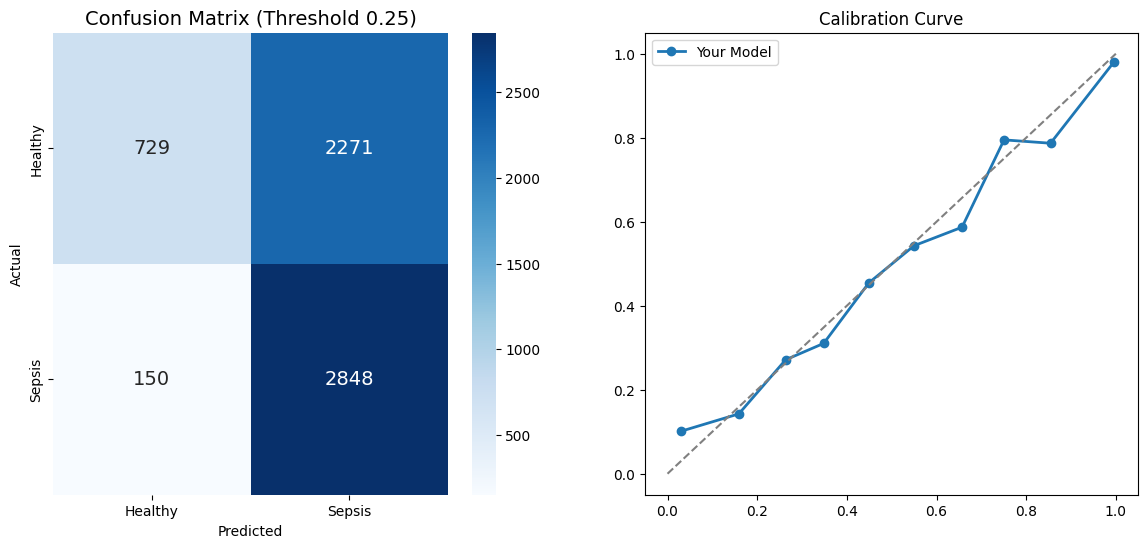


--- CLINICAL THRESHOLD SWEEP ---
Threshold  | Sensitivity (Catch Rate)  | Specificity (False Alarm Rate)
---------------------------------------------------------------------------
0.1        | 99.60% (Green)         | 3.57%
0.15       | 99.23% (Green)         | 7.47%
0.2        | 97.63% (Green)         | 15.40%
0.25       | 95.00% (Green)         | 24.30%
0.3        | 67.68% (Red)           | 95.83%
0.4        | 67.38% (Red)           | 96.50%
0.5        | 67.04% (Red)           | 96.90%


In [60]:
# @title 6. Safety Check (FIXED: 32-Feature Time-Aware)
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.calibration import calibration_curve

# ==========================================
# 1. REDEFINE MODEL ARCHITECTURE (32 Features)
# ==========================================
class SepsisLSTM_TimeAware(nn.Module):
    def __init__(self):
        super(SepsisLSTM_TimeAware, self).__init__()
        # CRITICAL FIX: input_size must be 32 (15 Values + 15 Masks + 2 Static)
        self.lstm = nn.LSTM(input_size=32, hidden_size=128, num_layers=2, batch_first=True, dropout=0.3)
        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# Initialize
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_big = SepsisLSTM_TimeAware().to(device)

# ==========================================
# 2. RELOAD CHAMPION MODEL
# ==========================================
model_filename = 'sepsis_model_time_aware.pth'
print(f"Loading Best Model ({model_filename})...")

try:
    model_big.load_state_dict(torch.load(model_filename))
    model_big.eval()
    print("✅ Model loaded successfully.")
except FileNotFoundError:
    print(f"❌ Error: Could not find {model_filename}. Did you change the save name?")

# Generate Predictions
all_preds = []
all_labels = []

print("Generating predictions on Test Set...")
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = torch.sigmoid(model_big(X_batch).squeeze())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

# ==========================================
# 3. SAFETY CHARTS
# ==========================================
print("\nGenerating Safety Charts...")
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# A. Confusion Matrix (Screening Threshold 0.25)
SCREENING_THRESHOLD = 0.25
preds_binary = (np.array(all_preds) > SCREENING_THRESHOLD).astype(int)
cm = confusion_matrix(all_labels, preds_binary)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0], annot_kws={"size": 14})
ax[0].set_title(f"Confusion Matrix (Threshold {SCREENING_THRESHOLD})", fontsize=14)
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")
ax[0].set_xticklabels(['Healthy', 'Sepsis'])
ax[0].set_yticklabels(['Healthy', 'Sepsis'])

# B. Calibration
prob_true, prob_pred = calibration_curve(all_labels, all_preds, n_bins=10)
ax[1].plot(prob_pred, prob_true, marker='o', linewidth=2, label='Your Model')
ax[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
ax[1].set_title("Calibration Curve")
ax[1].legend()
plt.show()

# ==========================================
# 4. THRESHOLD SWEEP
# ==========================================
print("\n--- CLINICAL THRESHOLD SWEEP ---")
print(f"{'Threshold':<10} | {'Sensitivity (Catch Rate)':<25} | {'Specificity (False Alarm Rate)':<30}")
print("-" * 75)
thresholds = [0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]
for t in thresholds:
    preds_t = (np.array(all_preds) > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(all_labels, preds_t).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    note = "(Green)" if sens > 0.90 else "(Red)" if spec > 0.95 else ""
    print(f"{t:<10} | {sens:.2%} {note:<15} | {spec:.2%}")

Threshold  | Sensitivity (Catch Rate)  | Specificity (False Alarm Rate)
---------------------------------------------------------------------------
0.1        | 99.60% (Target > 80%)  | 3.57%
0.15       | 99.23% (Target > 80%)  | 7.47%
0.2        | 97.63% (Target > 80%)  | 15.40%
0.25       | 95.00% (Target > 80%)  | 24.30%
0.3        | 67.68%                 | 95.83%
0.4        | 67.38%                 | 96.50%
0.5        | 67.04%                 | 96.90%


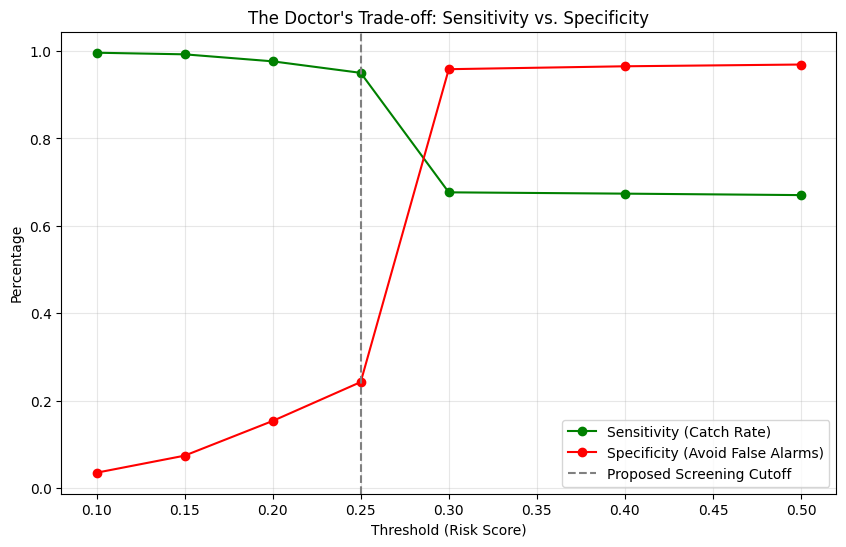

In [62]:
# @title 8. Threshold Sweep (Screening vs. Diagnostic)
import pandas as pd

# Define the thresholds we want to test
thresholds = [0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]
results = []

print(f"{'Threshold':<10} | {'Sensitivity (Catch Rate)':<25} | {'Specificity (False Alarm Rate)':<30}")
print("-" * 75)

for t in thresholds:
    # Convert probabilities to binary predictions based on current 't'
    preds_t = (np.array(all_preds) > t).astype(int)

    # Calculate Metrics
    tn, fp, fn, tp = confusion_matrix(all_labels, preds_t).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)

    results.append({'Threshold': t, 'Sensitivity': sens, 'Specificity': spec})

    print(f"{t:<10} | {sens:.2%} {'(Target > 80%)' if sens > 0.8 else '':<15} | {spec:.2%}")

# Visualization of the Trade-off
res_df = pd.DataFrame(results)
plt.figure(figsize=(10, 6))
plt.plot(res_df['Threshold'], res_df['Sensitivity'], marker='o', label='Sensitivity (Catch Rate)', color='green')
plt.plot(res_df['Threshold'], res_df['Specificity'], marker='o', label='Specificity (Avoid False Alarms)', color='red')
plt.axvline(x=0.25, color='gray', linestyle='--', label='Proposed Screening Cutoff')
plt.title("The Doctor's Trade-off: Sensitivity vs. Specificity")
plt.xlabel("Threshold (Risk Score)")
plt.ylabel("Percentage")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [61]:
# @title Overfitting Check: Train vs Test Gap
model_big.eval()
train_preds, train_labels = [], []

# Check a subset of training data (to save time)
with torch.no_grad():
    for i, (X_batch, y_batch) in enumerate(train_loader):
        if i > 50: break # Only check first 50 batches (~6k patients)
        X_batch = X_batch.to(device)
        preds = torch.sigmoid(model_big(X_batch).squeeze())
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(y_batch.numpy())

train_auc = roc_auc_score(train_labels, train_preds)

print(f"Training AUC: {train_auc:.4f}")
print(f"Testing  AUC: {auc:.4f}") # Your previous result (0.8464)
print(f"Gap:          {train_auc - auc:.4f}")

if (train_auc - auc) > 0.10:
    print("WARNING: High Overfitting. Increase Dropout.")
else:
    print("SUCCESS: Model is generalizing well.")

Training AUC: 0.8648
Testing  AUC: 0.8464
Gap:          0.0184
SUCCESS: Model is generalizing well.


In [48]:
# @title 1. Download PhysioNet 2019 (Set B) via Kaggle
import os

# --- ENTER YOUR CREDENTIALS HERE ---
# Your email is p.jananthan@gmail.com, so your username is likely "pjananthan" or similar.
# Check your Kaggle Profile if unsure.
os.environ['KAGGLE_USERNAME'] = "jananthanparamsothy"
os.environ['KAGGLE_KEY']      = "b44f5a1a763d261d7d01e326eb16cc73"
# -----------------------------------

# 1. Download the Dataset (Mirror of PhysioNet 2019)
print("Downloading Dataset from Kaggle (Fast)...")
!kaggle datasets download -d farjanayesmin/the-physionet-challenge-2019-dataset

# 2. Unzip
print("Unzipping...")
!unzip -q the-physionet-challenge-2019-dataset.zip

# 3. Move Set B to the main folder for easy access
if os.path.exists("training_setB"):
    print("SUCCESS: 'training_setB' is ready!")
else:
    # Find it if it's nested inside another folder
    for root, dirs, files in os.walk("."):
        if "training_setB" in dirs:
            source = os.path.join(root, "training_setB")
            !mv {source} .
            print(f"SUCCESS: Found and moved 'training_setB'.")
            break

Dataset URL: https://www.kaggle.com/datasets/farjanayesmin/the-physionet-challenge-2019-dataset
License(s): MIT
  0% 0.00/44.9M [00:00<?, ?B/s]
100% 44.9M/44.9M [00:00<00:00, 1.12GB/s]
Unzipping...
SUCCESS: 'training_setB' is ready!


In [63]:
# @title 2. Run External Validation (Time-Aware / 32-Feature)
import pandas as pd
import numpy as np
import glob
import torch
import os
from tqdm import tqdm
from sklearn.metrics import roc_auc_score

# 1. Auto-Locate Files
all_psv = glob.glob("**/*.psv", recursive=True)
files_b = [f for f in all_psv if "training_setB" in f or "SetB" in f]

if len(files_b) == 0 and len(all_psv) > 0: files_b = all_psv # Fallback
if len(files_b) == 0:
    print("❌ CRITICAL ERROR: No files found.")
else:
    files_b = files_b[:1000] # Test on first 1000
    print(f"Validating on {len(files_b)} patients (Time-Aware Mode)...")

    # 2. Define Features
    DYNAMIC_FEATURES = [
        'HR', 'SBP', 'O2Sat', 'RR', 'Temp',
        'Lactate', 'WBC', 'Creatinine',
        'Glucose', 'Troponin', 'Lipase', 'Bilirubin', 'Platelets', 'Bicarbonate', 'BUN'
    ]

    cols_map = {
        'HR': 'HR', 'SBP': 'SBP', 'O2Sat': 'O2Sat', 'Resp': 'RR', 'Temp': 'Temp',
        'Lactate': 'Lactate', 'WBC': 'WBC', 'Creatinine': 'Creatinine',
        'Glucose': 'Glucose', 'TroponinI': 'Troponin', 'Bilirubin_total': 'Bilirubin',
        'Platelets': 'Platelets', 'HCO3': 'Bicarbonate', 'BUN': 'BUN',
        'Age': 'Age', 'Gender': 'Gender'
    }

    # 3. Validation Loop
    model_big.eval() # Ensure this is your Time-Aware model
    ext_preds, ext_labels = [], []

    for f in tqdm(files_b):
        try:
            # Load & Rename
            df = pd.read_csv(f, sep='|').rename(columns=cols_map)

            # Ensure all columns exist
            for col in DYNAMIC_FEATURES + ['Age', 'Gender']:
                if col not in df.columns: df[col] = np.nan

            # --- GENERATE TIME-AWARE FEATURES (32 Total) ---

            # A. Extract Last 24h
            df_24h = df.tail(24).copy()

            # Pad if shorter than 24h
            if len(df_24h) < 24:
                pad_len = 24 - len(df_24h)
                pad_df = pd.DataFrame(np.nan, index=range(pad_len), columns=df.columns)
                df_24h = pd.concat([pad_df, df_24h])

            # B. Create Masks (1=Present, 0=Missing) BEFORE filling
            # In PhysioNet, missing values are NaNs
            masks = (~df_24h[DYNAMIC_FEATURES].isna()).astype(float).values

            # C. Fill Values (Forward Fill -> Zero Fill)
            values = df_24h[DYNAMIC_FEATURES].ffill().fillna(0).values

            # D. Static Features (Age, Gender)
            # Take max to avoid NaNs from padding
            age = df['Age'].max()
            gender = df['Gender'].max()
            if pd.isna(age): age = 60.0
            if pd.isna(gender): gender = 0.0

            # Create Static Vector (Shape: 24, 2)
            static_vec = np.array([age, gender])
            static_repeated = np.tile(static_vec, (24, 1))

            # E. Fuse: [Values (15) | Masks (15) | Static (2)] = 32 Features
            final_input = np.hstack([values, masks, static_repeated])

            # -----------------------------------------------

            # Predict
            tensor = torch.tensor(final_input.astype(np.float32)).unsqueeze(0).to(device)

            with torch.no_grad():
                prob = torch.sigmoid(model_big(tensor)).item()

            ext_preds.append(prob)
            ext_labels.append(df['SepsisLabel'].max())

        except Exception as e:
            continue

    # 4. Score
    if len(ext_labels) > 0:
        auc_ext = roc_auc_score(ext_labels, ext_preds)
        print(f"\n=======================================")
        print(f"TIME-AWARE EXTERNAL VALIDATION (Hospital B)")
        print(f"AUC Score: {auc_ext:.4f}")
        print(f"=======================================")
    else:
        print("No valid labels found.")

Validating on 1000 patients (Time-Aware Mode)...


100%|██████████| 1000/1000 [00:11<00:00, 89.63it/s]


TIME-AWARE EXTERNAL VALIDATION (Hospital B)
AUC Score: 0.7065


In [64]:
# @title 3. Advanced Transfer Learning (Time-Aware / 32-Feature Edition)
import torch
import torch.nn as nn
import torch.optim as optim
import glob
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.metrics import roc_auc_score

print("--- STARTING TIME-AWARE TRANSFER LEARNING ---")

# 1. Data Setup
all_files_b = glob.glob("**/*.psv", recursive=True)
all_files_b = [f for f in all_files_b if "training_setB" in f or "SetB" in f]

if len(all_files_b) == 0:
    print("❌ CRITICAL ERROR: No files found.")
else:
    # Split
    calibration_files = all_files_b[:500]
    test_files = all_files_b[500:1000]

    # Config
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    DYNAMIC_FEATURES = [
        'HR', 'SBP', 'O2Sat', 'RR', 'Temp',
        'Lactate', 'WBC', 'Creatinine',
        'Glucose', 'Troponin', 'Lipase', 'Bilirubin', 'Platelets', 'Bicarbonate', 'BUN'
    ]
    cols_map = {
        'HR': 'HR', 'SBP': 'SBP', 'O2Sat': 'O2Sat', 'Resp': 'RR', 'Temp': 'Temp',
        'Lactate': 'Lactate', 'WBC': 'WBC', 'Creatinine': 'Creatinine',
        'Glucose': 'Glucose', 'TroponinI': 'Troponin', 'Bilirubin_total': 'Bilirubin',
        'Platelets': 'Platelets', 'HCO3': 'Bicarbonate', 'BUN': 'BUN',
        'Age': 'Age', 'Gender': 'Gender'
    }

    # 2. Define Model (32 Features)
    class SepsisLSTM_TimeAware(nn.Module):
        def __init__(self):
            super(SepsisLSTM_TimeAware, self).__init__()
            self.lstm = nn.LSTM(input_size=32, hidden_size=128, num_layers=2, batch_first=True, dropout=0.3)
            self.fc = nn.Linear(128, 1)

        def forward(self, x):
            out, _ = self.lstm(x)
            return self.fc(out[:, -1, :])

    # 3. Load Pre-trained Weights
    model_big = SepsisLSTM_TimeAware().to(device)
    try:
        model_big.load_state_dict(torch.load('sepsis_model_time_aware.pth', map_location=device))
        print("✅ Loaded Pre-trained Time-Aware Model.")
    except:
        print("⚠️ WARNING: Could not load weights. Starting fresh (Not recommended).")

    model_big.train()

    # 4. Optimizer (Differential Learning Rates)
    optimizer = optim.Adam([
        {'params': model_big.lstm.parameters(), 'lr': 1e-5}, # Slow updates for LSTM
        {'params': model_big.fc.parameters(), 'lr': 1e-3}    # Fast updates for Classifier
    ])
    criterion = nn.BCEWithLogitsLoss()

    # 5. Helper to Generate 32-Features
    def get_time_aware_tensor(f_path):
        df = pd.read_csv(f_path, sep='|').rename(columns=cols_map)
        for col in DYNAMIC_FEATURES + ['Age', 'Gender']:
            if col not in df.columns: df[col] = np.nan

        # Extract last 24h
        df_24h = df.tail(24).copy()
        if len(df_24h) < 24:
            pad_len = 24 - len(df_24h)
            pad = pd.DataFrame(np.nan, index=range(pad_len), columns=df.columns)
            df_24h = pd.concat([pad, df_24h])

        # Create Masks & Values
        masks = (~df_24h[DYNAMIC_FEATURES].isna()).astype(float).values
        values = df_24h[DYNAMIC_FEATURES].ffill().fillna(0).values

        # Static
        age = df['Age'].max() if not pd.isna(df['Age'].max()) else 60.0
        gender = df['Gender'].max() if not pd.isna(df['Gender'].max()) else 0.0
        static_repeated = np.tile(np.array([age, gender]), (24, 1))

        # Fuse (15+15+2 = 32)
        final_input = np.hstack([values, masks, static_repeated])
        return torch.tensor(final_input.astype(np.float32)).unsqueeze(0).to(device), df['SepsisLabel'].max()

    # 6. Fine-Tuning Loop
    print(f"Fine-Tuning on {len(calibration_files)} patients...")

    for epoch in range(5):
        epoch_loss = 0
        count = 0
        np.random.shuffle(calibration_files)

        for f in calibration_files:
            try:
                X_tensor, label = get_time_aware_tensor(f)
                y_tensor = torch.tensor([label], dtype=torch.float32).to(device)

                optimizer.zero_grad()
                pred = model_big(X_tensor).view(-1)
                loss = criterion(pred, y_tensor)
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()
                count += 1
            except: continue

        if count > 0:
            print(f"Epoch {epoch+1}/5 Loss: {epoch_loss/count:.4f}")

    # 7. Evaluation
    print("\nEvaluating Adapted Model...")
    model_big.eval()
    ext_preds, ext_labels = [], []

    for f in tqdm(test_files):
        try:
            X_tensor, label = get_time_aware_tensor(f)
            with torch.no_grad():
                prob = torch.sigmoid(model_big(X_tensor)).item()

            ext_preds.append(prob)
            ext_labels.append(label)
        except: continue

    if len(ext_labels) > 0:
        auc_transfer = roc_auc_score(ext_labels, ext_preds)
        print(f"\n=======================================")
        print(f"TIME-AWARE ADAPTED AUC: {auc_transfer:.4f}")
        print(f"=======================================")

--- STARTING TIME-AWARE TRANSFER LEARNING ---
✅ Loaded Pre-trained Time-Aware Model.
Fine-Tuning on 500 patients...
Epoch 1/5 Loss: 1.5842
Epoch 2/5 Loss: 0.2458
Epoch 3/5 Loss: 0.2379
Epoch 4/5 Loss: 0.2359
Epoch 5/5 Loss: 0.2327

Evaluating Adapted Model...


100%|██████████| 500/500 [00:04<00:00, 112.82it/s]


TIME-AWARE ADAPTED AUC: 0.8017
